# Test


## Animation

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import os
import glob
from PIL import Image
from typing import List


def fruchterman_reingold_step(
    pos: np.ndarray, A: np.ndarray, k: float, t: float, clip_value: float
) -> np.ndarray:
    delta = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]
    distance = np.linalg.norm(delta, axis=-1)
    np.clip(distance, 0.01, None, out=distance)
    displacement = np.einsum(
        "ijk,ij->ik", delta, (k * k / distance**2 - A * distance / k)
    )
    length = np.linalg.norm(displacement, axis=-1)
    length = np.where(length < 0.01, clip_value, length)
    delta_pos = np.einsum("ij,i->ij", displacement, t / length)
    return pos + delta_pos


def simulate_layout(
    G: nx.Graph,
    initial_pos: np.ndarray,
    clip_value: float,
    k: float,
    iterations,
    threshold: float = 1e-4,
) -> List[np.ndarray]:
    A = nx.to_numpy_array(G)
    pos = initial_pos.copy()
    positions = [pos.copy()]
    t = max(max(pos.T[0]) - min(pos.T[0]), max(pos.T[1]) - min(pos.T[1])) * 0.1
    dt = t / (iterations + 1)

    for iteration in range(iterations):
        new_pos = fruchterman_reingold_step(pos, A, k, t, clip_value)
        delta_pos = new_pos - pos
        pos = new_pos
        positions.append(pos.copy())
        t -= dt
        if np.linalg.norm(delta_pos) < threshold:
            break

    return positions


def draw_graph_frame(
    G: nx.Graph, pos: np.ndarray, ax: plt.Axes, title: str, iteration: int
) -> None:
    ax.clear()

    allnodes = list(G.nodes)
    pos_dict = {n: pos[i] for i, n in enumerate(allnodes)}

    nx.draw_networkx_edges(G, pos=pos_dict, ax=ax, width=3, edge_color="lightgrey")
    nx.draw_networkx_nodes(
        G,
        pos=pos_dict,
        ax=ax,
        node_size=600,
        node_color="tab:orange",
        nodelist=allnodes,
    )

    ax.set_title(title, fontsize=16)
    if iteration is not None:
        ax.text(
            0.02,
            0.98,
            f"Iteration {iteration}",
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment="top",
        )
    ax.axis("off")


def create_initial_positions(G) -> np.ndarray:
    if G.name == "Desargues Graph":
        positions = []
        for theta in np.linspace(0, 2 * np.pi, G.number_of_nodes(), endpoint=False):
            positions.append(np.array([np.cos(theta), np.sin(theta)]))
        return np.array(positions)
    else:
        np.random.seed(0)
        return np.random.rand(G.number_of_nodes(), 2)


def save_comparison_frames(G, clip_values: List[float], k: float) -> None:
    os.makedirs("frames", exist_ok=True)

    initial_pos = create_initial_positions(G)

    print("Running simulation 1...")
    positions1 = simulate_layout(G, initial_pos, clip_values[0], k, 50)

    print("Running simulation 2...")
    positions2 = simulate_layout(G, initial_pos, clip_values[1], k, 50)

    max_frames = min(len(positions1), len(positions2))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))

    for i in range(max_frames):
        draw_graph_frame(G, positions1[i], ax1, f"Clip Value = {clip_values[0]}", i)
        draw_graph_frame(G, positions2[i], ax2, f"Clip Value = {clip_values[1]}", i)

        plt.tight_layout()
        plt.savefig(f"frames/frame_{i:04d}.png", bbox_inches="tight")
        print(f"Saved frame {i}")

    plt.close(fig)
    print(f"All {max_frames} frames saved.")


def create_gif_from_frames(name: str):
    frame_files = sorted(glob.glob("frames/frame_*.png"))

    if not frame_files:
        print("No frame files found in 'frames' directory")
        return

    images = []
    for frame_file in frame_files:
        img = Image.open(frame_file)
        images.append(img)

    images[0].save(
        f"{name}.gif", save_all=True, append_images=images[1:], duration=200, loop=0
    )

    print("GIF saved.")


if __name__ == "__main__":
    G = nx.desargues_graph()
    save_comparison_frames(G, [0.1, 0.01], k=0.3)
    create_gif_from_frames("desargues")

    n = 10
    A = np.zeros((n, n))
    for i in range(n):
        A[i][(i + 1) % n] = 1e-3
    G = nx.from_numpy_array(A)
    save_comparison_frames(G, [0.1, 0.01], k=1e-2)
    create_gif_from_frames("circle")


Running simulation 1...
Running simulation 2...
Saved frame 0
Saved frame 1
Saved frame 2
Saved frame 3
Saved frame 4
Saved frame 5
Saved frame 6
Saved frame 7
Saved frame 8
Saved frame 9
Saved frame 10
Saved frame 11
Saved frame 12
Saved frame 13
Saved frame 14
Saved frame 15
Saved frame 16
Saved frame 17
Saved frame 18
Saved frame 19
Saved frame 20
Saved frame 21
Saved frame 22
Saved frame 23
Saved frame 24
Saved frame 25
Saved frame 26
Saved frame 27
Saved frame 28
Saved frame 29
Saved frame 30
Saved frame 31
Saved frame 32
Saved frame 33
Saved frame 34
Saved frame 35
Saved frame 36
Saved frame 37
Saved frame 38
Saved frame 39
Saved frame 40
Saved frame 41
Saved frame 42
Saved frame 43
Saved frame 44
Saved frame 45
Saved frame 46
Saved frame 47
Saved frame 48
Saved frame 49
Saved frame 50
All 51 frames saved.
GIF saved.
Running simulation 1...
Running simulation 2...
Saved frame 0
Saved frame 1
Saved frame 2
Saved frame 3
Saved frame 4
Saved frame 5
Saved frame 6
Saved frame 7
Saved

## Comparison

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import time
import tqdm.auto as tqdm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx


def make_fig(
    Gs: list, methods: list, file_name: str, legend_pos=1.0, rect_pos=0.96, rows=2
):
    assert len(Gs) % rows == 0

    n2 = len(Gs) // rows
    fig, axes = plt.subplots(
        rows * len(methods), n2, figsize=(3 * n2, 3 * rows * len(methods))
    )
    axes = axes.flatten()

    progress = tqdm.tqdm(total=len(Gs) * len(methods))

    for i, (G, graph_name) in enumerate(Gs):
        print(f"Processing graph: {graph_name}")
        for j, (draw_func, _, node_color, kwargs) in enumerate(methods):
            ax = axes[i % n2 + j * n2 + len(methods) * n2 * int(i / n2)]

            t0 = time.perf_counter()
            try:
                pos = draw_func(G, **kwargs)
            except ValueError as e:
                print(f"Error: {e}")
                pos = np.zeros((len(G), 2))
            t1 = time.perf_counter()

            if isinstance(pos, np.ndarray):
                nodes = G.nodes()
                pos = dict(zip(nodes, pos))

            if j == 0:
                if graph_name.endswith("_graph"):
                    graph_name = graph_name[:-6]
                if graph_name == "dorogovtsev_goltsev_mendes":
                    graph_name = "DGM"
                ax.set_title(f"{graph_name}\n{t1 - t0:.2f}s", fontsize=20)
            else:
                ax.set_title(f"{t1 - t0:.2f}s", fontsize=20)

            nx.draw(
                G,
                pos=pos,
                ax=ax,
                node_size=min(50, max(5, 5000 // len(G))),
                node_color=node_color,
            )
            ax.axis("on")
            progress.update(1)

    handles = []
    for _, func_name, color, _ in methods:
        handles.append(mpatches.Patch(color=color, label=func_name))

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=len(handles),
        bbox_to_anchor=(0.5, legend_pos),
        fontsize=30,
    )

    plt.tight_layout(rect=(0, 0, 1, rect_pos))
    plt.savefig(file_name)
    plt.show()

In [33]:
from networkx.utils import np_random_state


def _process_params(G, center, dim):
    # Some boilerplate code.
    import numpy as np

    if not isinstance(G, nx.Graph):
        empty_graph = nx.Graph()
        empty_graph.add_nodes_from(G)
        G = empty_graph

    if center is None:
        center = np.zeros(dim)
    else:
        center = np.asarray(center)

    if len(center) != dim:
        msg = "length of center coordinates must match dimension of layout"
        raise ValueError(msg)

    return G, center


def rescale_layout(pos, scale=1):
    """Returns scaled position array to (-scale, scale) in all axes.

    The function acts on NumPy arrays which hold position information.
    Each position is one row of the array. The dimension of the space
    equals the number of columns. Each coordinate in one column.

    To rescale, the mean (center) is subtracted from each axis separately.
    Then all values are scaled so that the largest magnitude value
    from all axes equals `scale` (thus, the aspect ratio is preserved).
    The resulting NumPy Array is returned (order of rows unchanged).

    Parameters
    ----------
    pos : numpy array
        positions to be scaled. Each row is a position.

    scale : number (default: 1)
        The size of the resulting extent in all directions.

    attribute : str, default None
        If non-None, the position of each node will be stored on the graph as
        an attribute named `attribute` which can be accessed with
        `G.nodes[...][attribute]`. The function still returns the dictionary.

    Returns
    -------
    pos : numpy array
        scaled positions. Each row is a position.

    See Also
    --------
    rescale_layout_dict
    """
    import numpy as np

    # Find max length over all dimensions
    pos -= pos.mean(axis=0)
    lim = np.abs(pos).max()  # max coordinate for all axes
    # rescale to (-scale, scale) in all directions, preserves aspect
    if lim > 0:
        pos *= scale / lim
    return pos


@np_random_state(10)
def spring_layout(
    G,
    k=None,
    pos=None,
    fixed=None,
    iterations=50,
    threshold=1e-4,
    weight="weight",
    scale=1,
    center=None,
    dim=2,
    seed=None,
    store_pos_as=None,
    *,
    method="auto",
    gravity=1.0,
    clipping_value=0.01,
):
    """Position nodes using Fruchterman-Reingold force-directed algorithm.

    The algorithm simulates a force-directed representation of the network
    treating edges as springs holding nodes close, while treating nodes
    as repelling objects, sometimes called an anti-gravity force.
    Simulation continues until the positions are close to an equilibrium.

    There are some hard-coded values: minimal distance between
    nodes (0.01) and "temperature" of 0.1 to ensure nodes don't fly away.
    During the simulation, `k` helps determine the distance between nodes,
    though `scale` and `center` determine the size and place after
    rescaling occurs at the end of the simulation.

    Fixing some nodes doesn't allow them to move in the simulation.
    It also turns off the rescaling feature at the simulation's end.
    In addition, setting `scale` to `None` turns off rescaling.

    Parameters
    ----------
    G : NetworkX graph or list of nodes
        A position will be assigned to every node in G.

    k : float (default=None)
        Optimal distance between nodes.  If None the distance is set to
        1/sqrt(n) where n is the number of nodes.  Increase this value
        to move nodes farther apart.

    pos : dict or None  optional (default=None)
        Initial positions for nodes as a dictionary with node as keys
        and values as a coordinate list or tuple.  If None, then use
        random initial positions.

    fixed : list or None  optional (default=None)
        Nodes to keep fixed at initial position.
        Nodes not in ``G.nodes`` are ignored.
        ValueError raised if `fixed` specified and `pos` not.

    iterations : int  optional (default=50)
        Maximum number of iterations taken

    threshold: float optional (default = 1e-4)
        Threshold for relative error in node position changes.
        The iteration stops if the error is below this threshold.

    weight : string or None   optional (default='weight')
        The edge attribute that holds the numerical value used for
        the edge weight.  Larger means a stronger attractive force.
        If None, then all edge weights are 1.

    scale : number or None (default: 1)
        Scale factor for positions. Not used unless `fixed is None`.
        If scale is None, no rescaling is performed.

    center : array-like or None
        Coordinate pair around which to center the layout.
        Not used unless `fixed is None`.

    dim : int
        Dimension of layout.

    seed : int, RandomState instance or None  optional (default=None)
        Used only for the initial positions in the algorithm.
        Set the random state for deterministic node layouts.
        If int, `seed` is the seed used by the random number generator,
        if numpy.random.RandomState instance, `seed` is the random
        number generator,
        if None, the random number generator is the RandomState instance used
        by numpy.random.

    store_pos_as : str, default None
        If non-None, the position of each node will be stored on the graph as
        an attribute with this string as its name, which can be accessed with
        ``G.nodes[...][store_pos_as]``. The function still returns the dictionary.

    method : str  optional (default='auto')
        The method to compute the layout.
        If 'force', the force-directed Fruchterman-Reingold algorithm [1]_ is used.
        If 'energy', the energy-based optimization algorithm [2]_ is used with absolute
        values of edge weights and gravitational forces acting on each connected component.
        If 'auto', we use 'force' if ``len(G) < 500`` and 'energy' otherwise.

    gravity: float optional (default=1.0)
        Used only for the method='energy'.
        The positive coefficient of gravitational forces per connected component.

    Returns
    -------
    pos : dict
        A dictionary of positions keyed by node

    Examples
    --------
    >>> from pprint import pprint
    >>> G = nx.path_graph(4)
    >>> pos = nx.spring_layout(G)
    >>> # suppress the returned dict and store on the graph directly
    >>> _ = nx.spring_layout(G, seed=123, store_pos_as="pos")
    >>> pprint(nx.get_node_attributes(G, "pos"))
    {0: array([-0.61520994, -1.        ]),
     1: array([-0.21840965, -0.35501755]),
     2: array([0.21841264, 0.35502078]),
     3: array([0.61520696, 0.99999677])}

    # The same using longer but equivalent function name
    >>> pos = nx.fruchterman_reingold_layout(G)

    References
    ----------
    .. [1] Fruchterman, Thomas MJ, and Edward M. Reingold.
           "Graph drawing by force-directed placement."
           Software: Practice and experience 21, no. 11 (1991): 1129-1164.
           http://dx.doi.org/10.1002/spe.4380211102
    .. [2] Hamaguchi, Hiroki, Naoki Marumo, and Akiko Takeda.
           "Initial Placement for Fruchterman--Reingold Force Model With Coordinate Newton Direction."
           arXiv preprint arXiv:2412.20317 (2024).
           https://arxiv.org/abs/2412.20317
    """
    import numpy as np

    if method not in ("auto", "force", "energy"):
        raise ValueError("the method must be either auto, force, or energy.")
    if method == "auto":
        method = "force" if len(G) < 500 else "energy"

    G, center = _process_params(G, center, dim)

    if fixed is not None:
        if pos is None:
            raise ValueError("nodes are fixed without positions given")
        for node in fixed:
            if node not in pos:
                raise ValueError("nodes are fixed without positions given")
        nfixed = {node: i for i, node in enumerate(G)}
        fixed = np.asarray([nfixed[node] for node in fixed if node in nfixed])

    if pos is not None:
        # Determine size of existing domain to adjust initial positions
        dom_size = max(coord for pos_tup in pos.values() for coord in pos_tup)
        if dom_size == 0:
            dom_size = 1
        pos_arr = seed.rand(len(G), dim) * dom_size + center

        for i, n in enumerate(G):
            if n in pos:
                pos_arr[i] = np.asarray(pos[n])
    else:
        pos_arr = None
        dom_size = 1

    if len(G) == 0:
        return {}
    if len(G) == 1:
        pos = {nx.utils.arbitrary_element(G.nodes()): center}
        if store_pos_as is not None:
            nx.set_node_attributes(G, pos, store_pos_as)
        return pos

    # Sparse matrix
    if len(G) >= 500 or method == "energy":
        A = nx.to_scipy_sparse_array(G, weight=weight, dtype="f")
        if k is None and fixed is not None:
            # We must adjust k by domain size for layouts not near 1x1
            nnodes, _ = A.shape
            k = dom_size / np.sqrt(nnodes)
        pos = _sparse_fruchterman_reingold(
            A, k, pos_arr, fixed, iterations, threshold, dim, seed, method, gravity
        )
    else:
        A = nx.to_numpy_array(G, weight=weight)
        if k is None and fixed is not None:
            # We must adjust k by domain size for layouts not near 1x1
            nnodes, _ = A.shape
            k = dom_size / np.sqrt(nnodes)
        pos = _fruchterman_reingold(
            A, k, pos_arr, fixed, iterations, threshold, dim, seed, clipping_value
        )
    if fixed is None and scale is not None:
        pos = rescale_layout(pos, scale=scale) + center
    pos = dict(zip(G, pos))

    if store_pos_as is not None:
        nx.set_node_attributes(G, pos, store_pos_as)

    return pos


fruchterman_reingold_layout = spring_layout


@np_random_state(7)
def _fruchterman_reingold(
    A,
    k=None,
    pos=None,
    fixed=None,
    iterations=50,
    threshold=1e-4,
    dim=2,
    seed=None,
    clipping_value=0.01,
):
    # Position nodes in adjacency matrix A using Fruchterman-Reingold
    # Entry point for NetworkX graph is fruchterman_reingold_layout()
    import numpy as np

    try:
        nnodes, _ = A.shape
    except AttributeError as err:
        msg = "fruchterman_reingold() takes an adjacency matrix as input"
        raise nx.NetworkXError(msg) from err

    if pos is None:
        # random initial positions
        pos = np.asarray(seed.rand(nnodes, dim), dtype=A.dtype)
    else:
        # make sure positions are of same type as matrix
        pos = pos.astype(A.dtype)

    # optimal distance between nodes
    if k is None:
        k = np.sqrt(1.0 / nnodes)
    # the initial "temperature"  is about .1 of domain area (=1x1)
    # this is the largest step allowed in the dynamics.
    # We need to calculate this in case our fixed positions force our domain
    # to be much bigger than 1x1
    t = max(max(pos.T[0]) - min(pos.T[0]), max(pos.T[1]) - min(pos.T[1])) * 0.1
    # simple cooling scheme.
    # linearly step down by dt on each iteration so last iteration is size dt.
    dt = t / (iterations + 1)
    delta = np.zeros((pos.shape[0], pos.shape[0], pos.shape[1]), dtype=A.dtype)
    # the inscrutable (but fast) version
    # this is still O(V^2)
    # could use multilevel methods to speed this up significantly
    for iteration in range(iterations):
        # matrix of difference between points
        delta = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]
        # distance between points
        distance = np.linalg.norm(delta, axis=-1)
        # enforce minimum distance of 0.01
        np.clip(distance, 0.01, None, out=distance)
        # displacement "force"
        displacement = np.einsum(
            "ijk,ij->ik", delta, (k * k / distance**2 - A * distance / k)
        )
        # update positions
        length = np.linalg.norm(displacement, axis=-1)

        cnt = np.count_nonzero(length < 0.01)
        if cnt > 0:
            print(f"Iter {iteration}: {cnt} nodes have length < 0.01")

        length = np.where(length < 0.01, clipping_value, length)
        delta_pos = np.einsum("ij,i->ij", displacement, t / length)
        if fixed is not None:
            # don't change positions of fixed nodes
            delta_pos[fixed] = 0.0
        pos += delta_pos
        # cool temperature
        t -= dt
        if (np.linalg.norm(delta_pos) / nnodes) < threshold:
            break
    return pos


  0%|          | 0/42 [00:00<?, ?it/s]

Processing graph: complete_graph
Iter 34: 1 nodes have length < 0.01
Processing graph: path_graph
Iter 43: 1 nodes have length < 0.01
Iter 45: 1 nodes have length < 0.01
Iter 47: 1 nodes have length < 0.01
Iter 48: 1 nodes have length < 0.01
Processing graph: cycle_graph
Iter 30: 1 nodes have length < 0.01
Iter 43: 1 nodes have length < 0.01
Iter 47: 1 nodes have length < 0.01
Iter 49: 2 nodes have length < 0.01
Processing graph: circular_ladder_graph
Iter 38: 1 nodes have length < 0.01
Iter 40: 2 nodes have length < 0.01
Iter 44: 2 nodes have length < 0.01
Iter 48: 3 nodes have length < 0.01
Iter 49: 1 nodes have length < 0.01
Processing graph: wheel_graph
Iter 44: 1 nodes have length < 0.01
Iter 46: 2 nodes have length < 0.01
Iter 47: 1 nodes have length < 0.01
Iter 49: 1 nodes have length < 0.01
Processing graph: star_graph
Iter 38: 2 nodes have length < 0.01
Iter 39: 1 nodes have length < 0.01
Iter 44: 1 nodes have length < 0.01
Iter 45: 1 nodes have length < 0.01
Iter 47: 5 nodes 

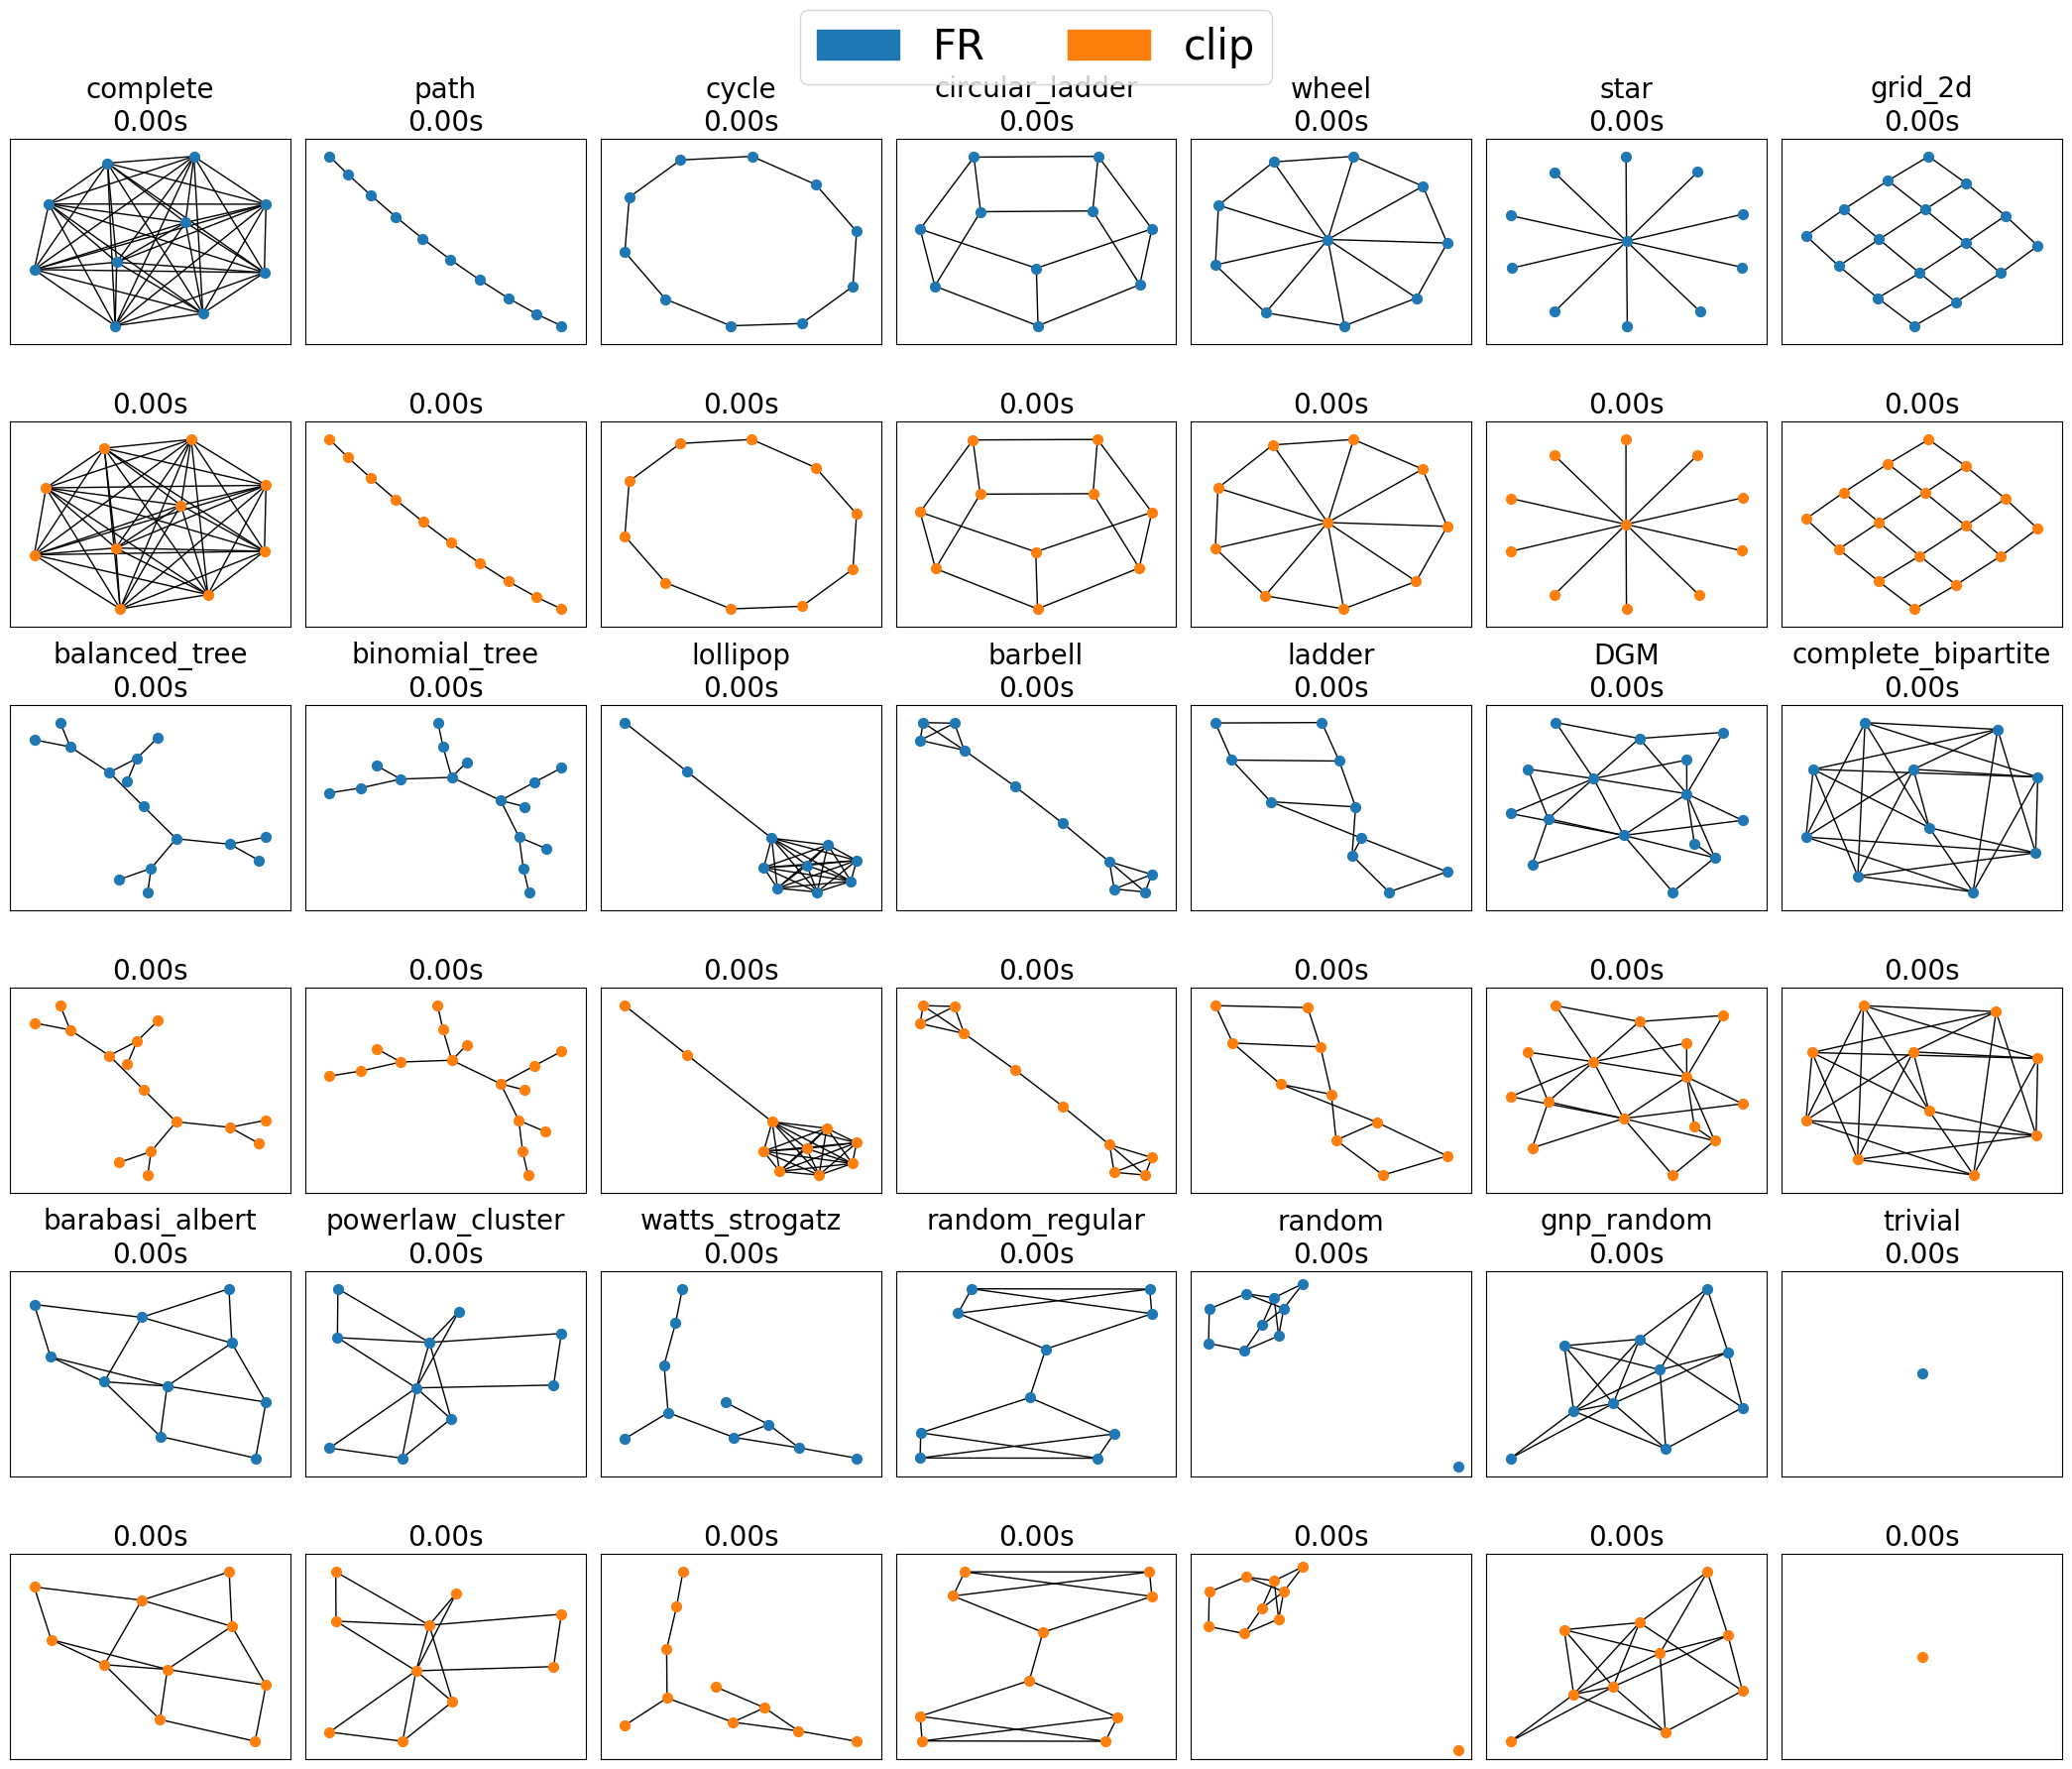

  0%|          | 0/42 [00:00<?, ?it/s]

Processing graph: complete_graph
Processing graph: path_graph
Iter 24: 1 nodes have length < 0.01
Iter 46: 1 nodes have length < 0.01
Iter 47: 1 nodes have length < 0.01
Processing graph: cycle_graph
Processing graph: circular_ladder_graph
Iter 45: 1 nodes have length < 0.01
Iter 47: 1 nodes have length < 0.01
Processing graph: wheel_graph
Iter 42: 1 nodes have length < 0.01
Iter 43: 1 nodes have length < 0.01
Iter 45: 1 nodes have length < 0.01
Iter 46: 2 nodes have length < 0.01
Iter 47: 3 nodes have length < 0.01
Iter 48: 1 nodes have length < 0.01
Iter 49: 3 nodes have length < 0.01
Processing graph: star_graph
Iter 19: 1 nodes have length < 0.01
Iter 34: 1 nodes have length < 0.01
Iter 42: 3 nodes have length < 0.01
Iter 43: 1 nodes have length < 0.01
Iter 44: 2 nodes have length < 0.01
Iter 45: 4 nodes have length < 0.01
Iter 46: 2 nodes have length < 0.01
Iter 47: 7 nodes have length < 0.01
Iter 48: 14 nodes have length < 0.01
Iter 49: 14 nodes have length < 0.01
Processing grap

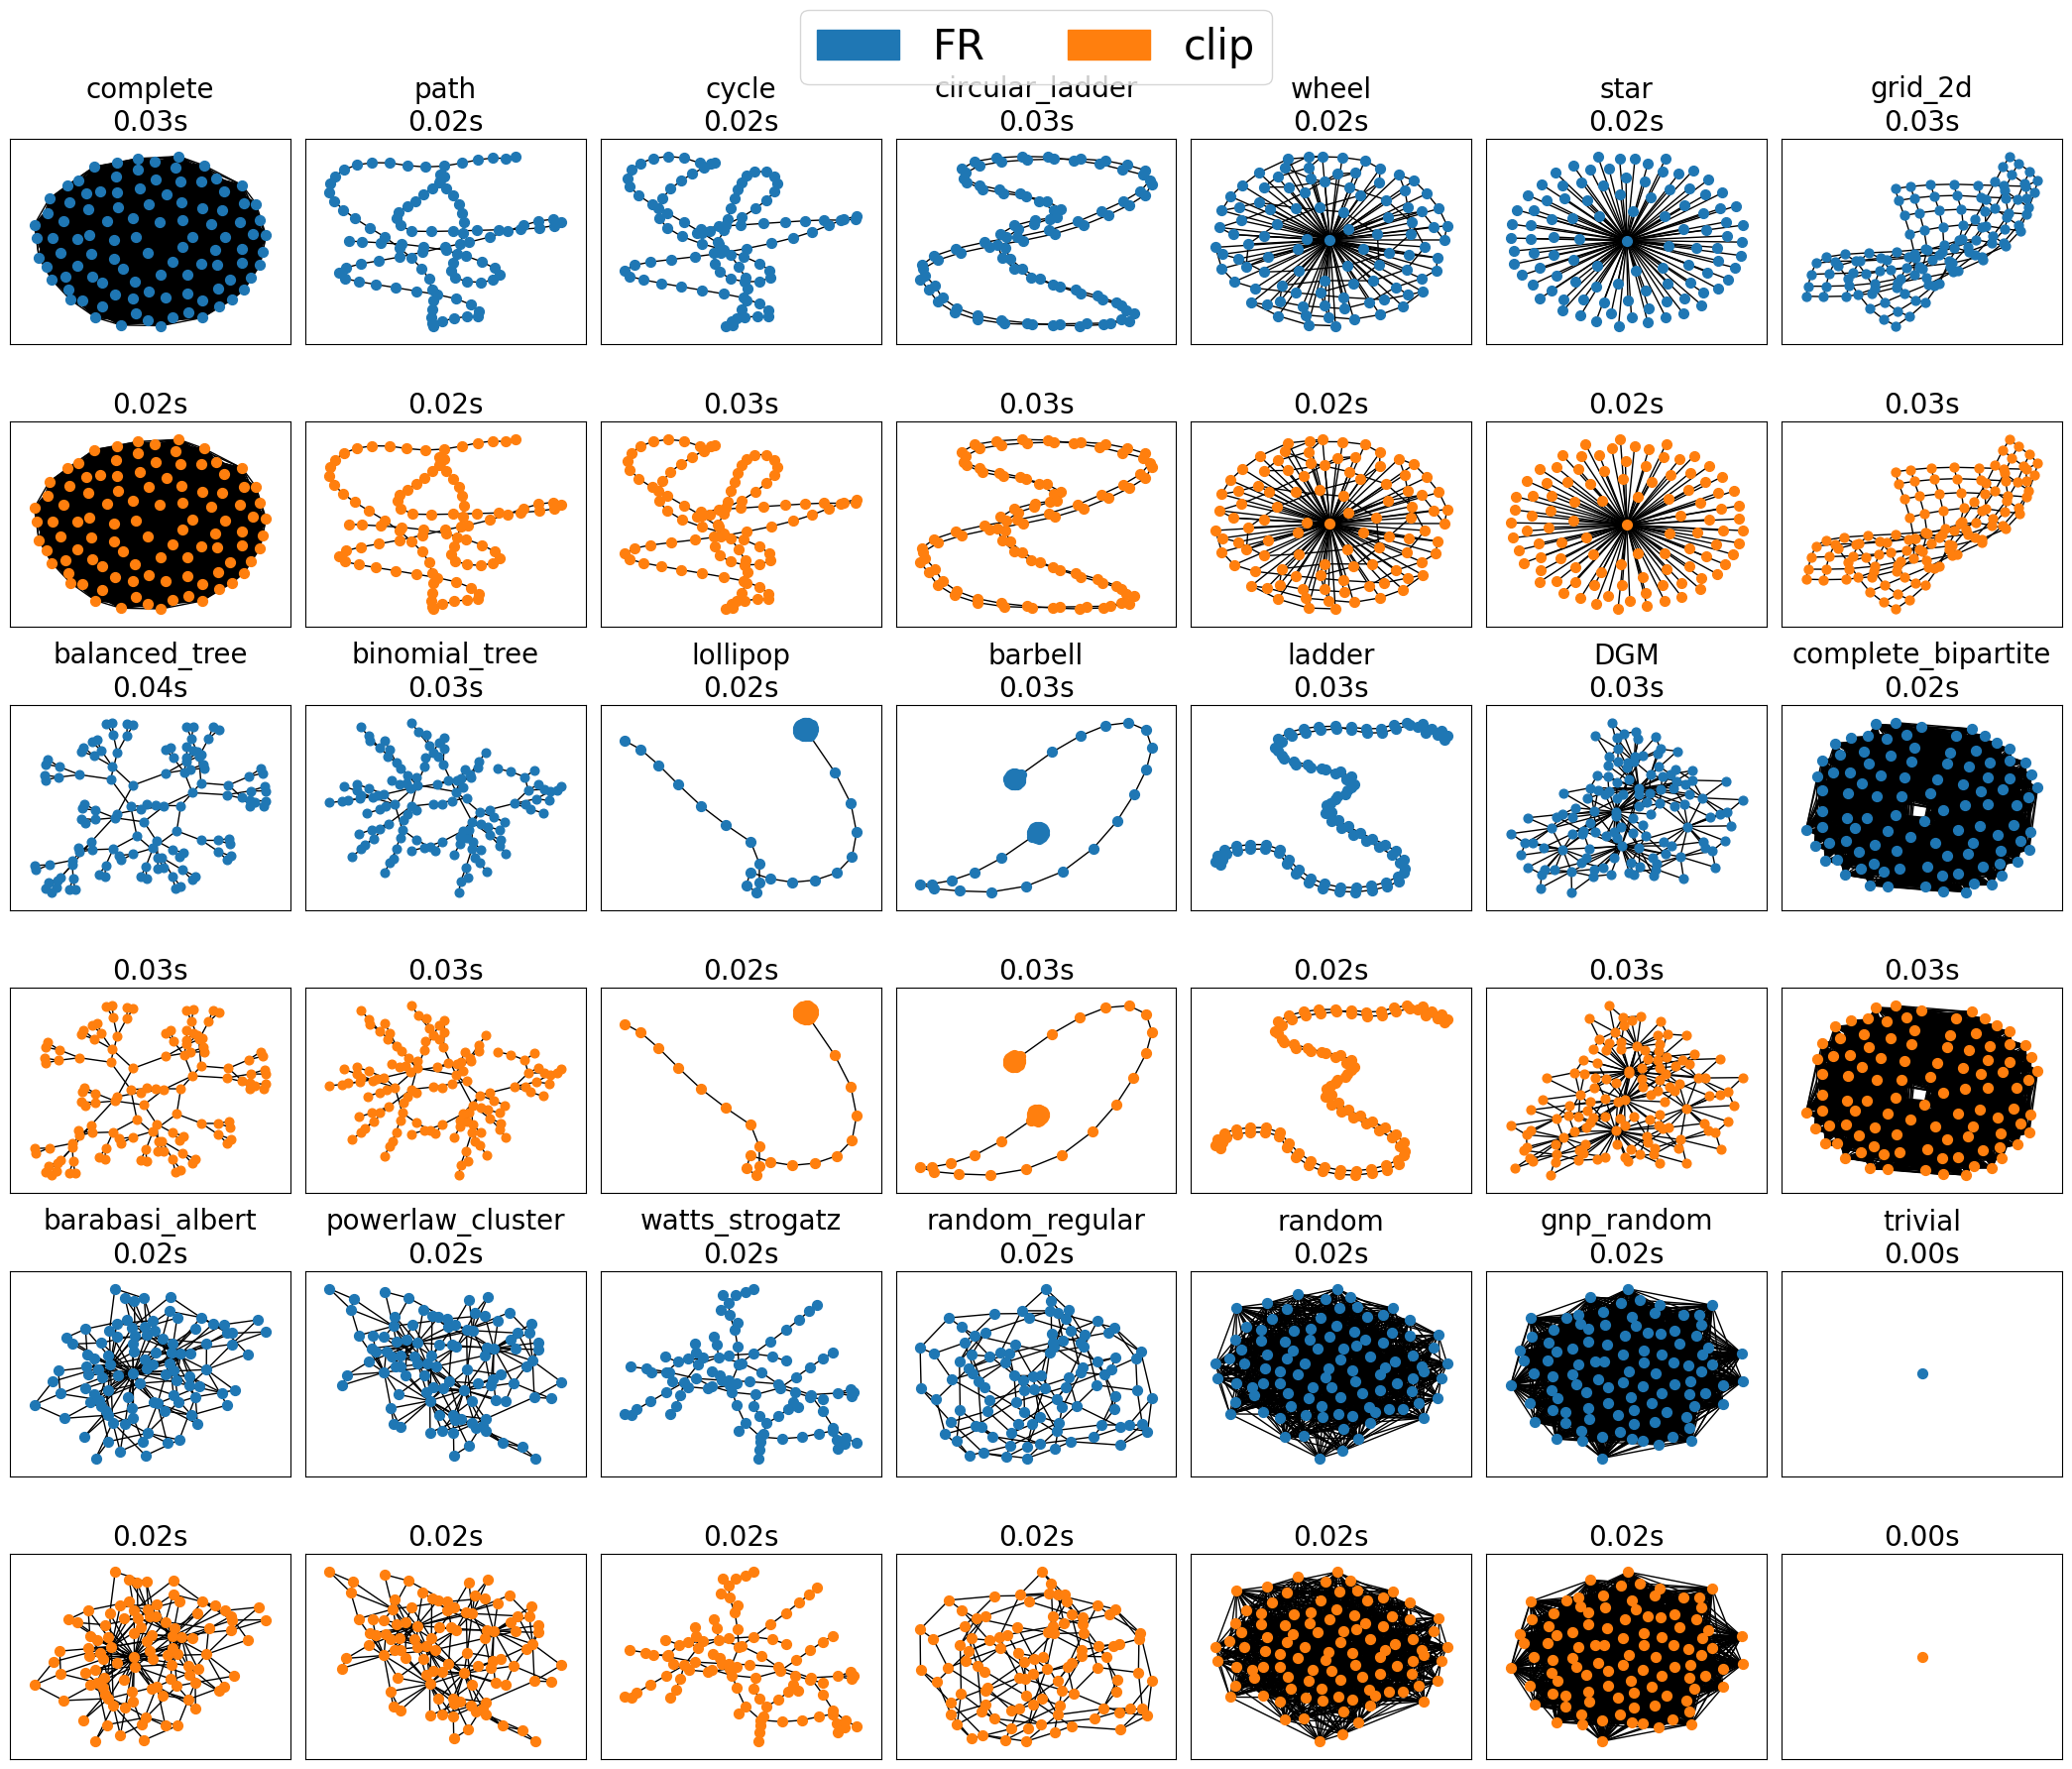

  0%|          | 0/42 [00:00<?, ?it/s]

Processing graph: complete_graph
Processing graph: path_graph
Iter 39: 1 nodes have length < 0.01
Iter 48: 1 nodes have length < 0.01
Processing graph: cycle_graph
Processing graph: circular_ladder_graph
Iter 38: 1 nodes have length < 0.01
Iter 46: 1 nodes have length < 0.01
Iter 47: 2 nodes have length < 0.01
Iter 49: 1 nodes have length < 0.01
Processing graph: wheel_graph
Iter 4: 1 nodes have length < 0.01
Iter 40: 1 nodes have length < 0.01
Iter 44: 1 nodes have length < 0.01
Iter 45: 1 nodes have length < 0.01
Iter 46: 1 nodes have length < 0.01
Iter 47: 2 nodes have length < 0.01
Iter 48: 4 nodes have length < 0.01
Iter 49: 3 nodes have length < 0.01
Processing graph: star_graph
Iter 14: 1 nodes have length < 0.01
Iter 23: 1 nodes have length < 0.01
Iter 24: 1 nodes have length < 0.01
Iter 34: 1 nodes have length < 0.01
Iter 40: 2 nodes have length < 0.01
Iter 41: 1 nodes have length < 0.01
Iter 42: 2 nodes have length < 0.01
Iter 44: 7 nodes have length < 0.01
Iter 45: 1 nodes h

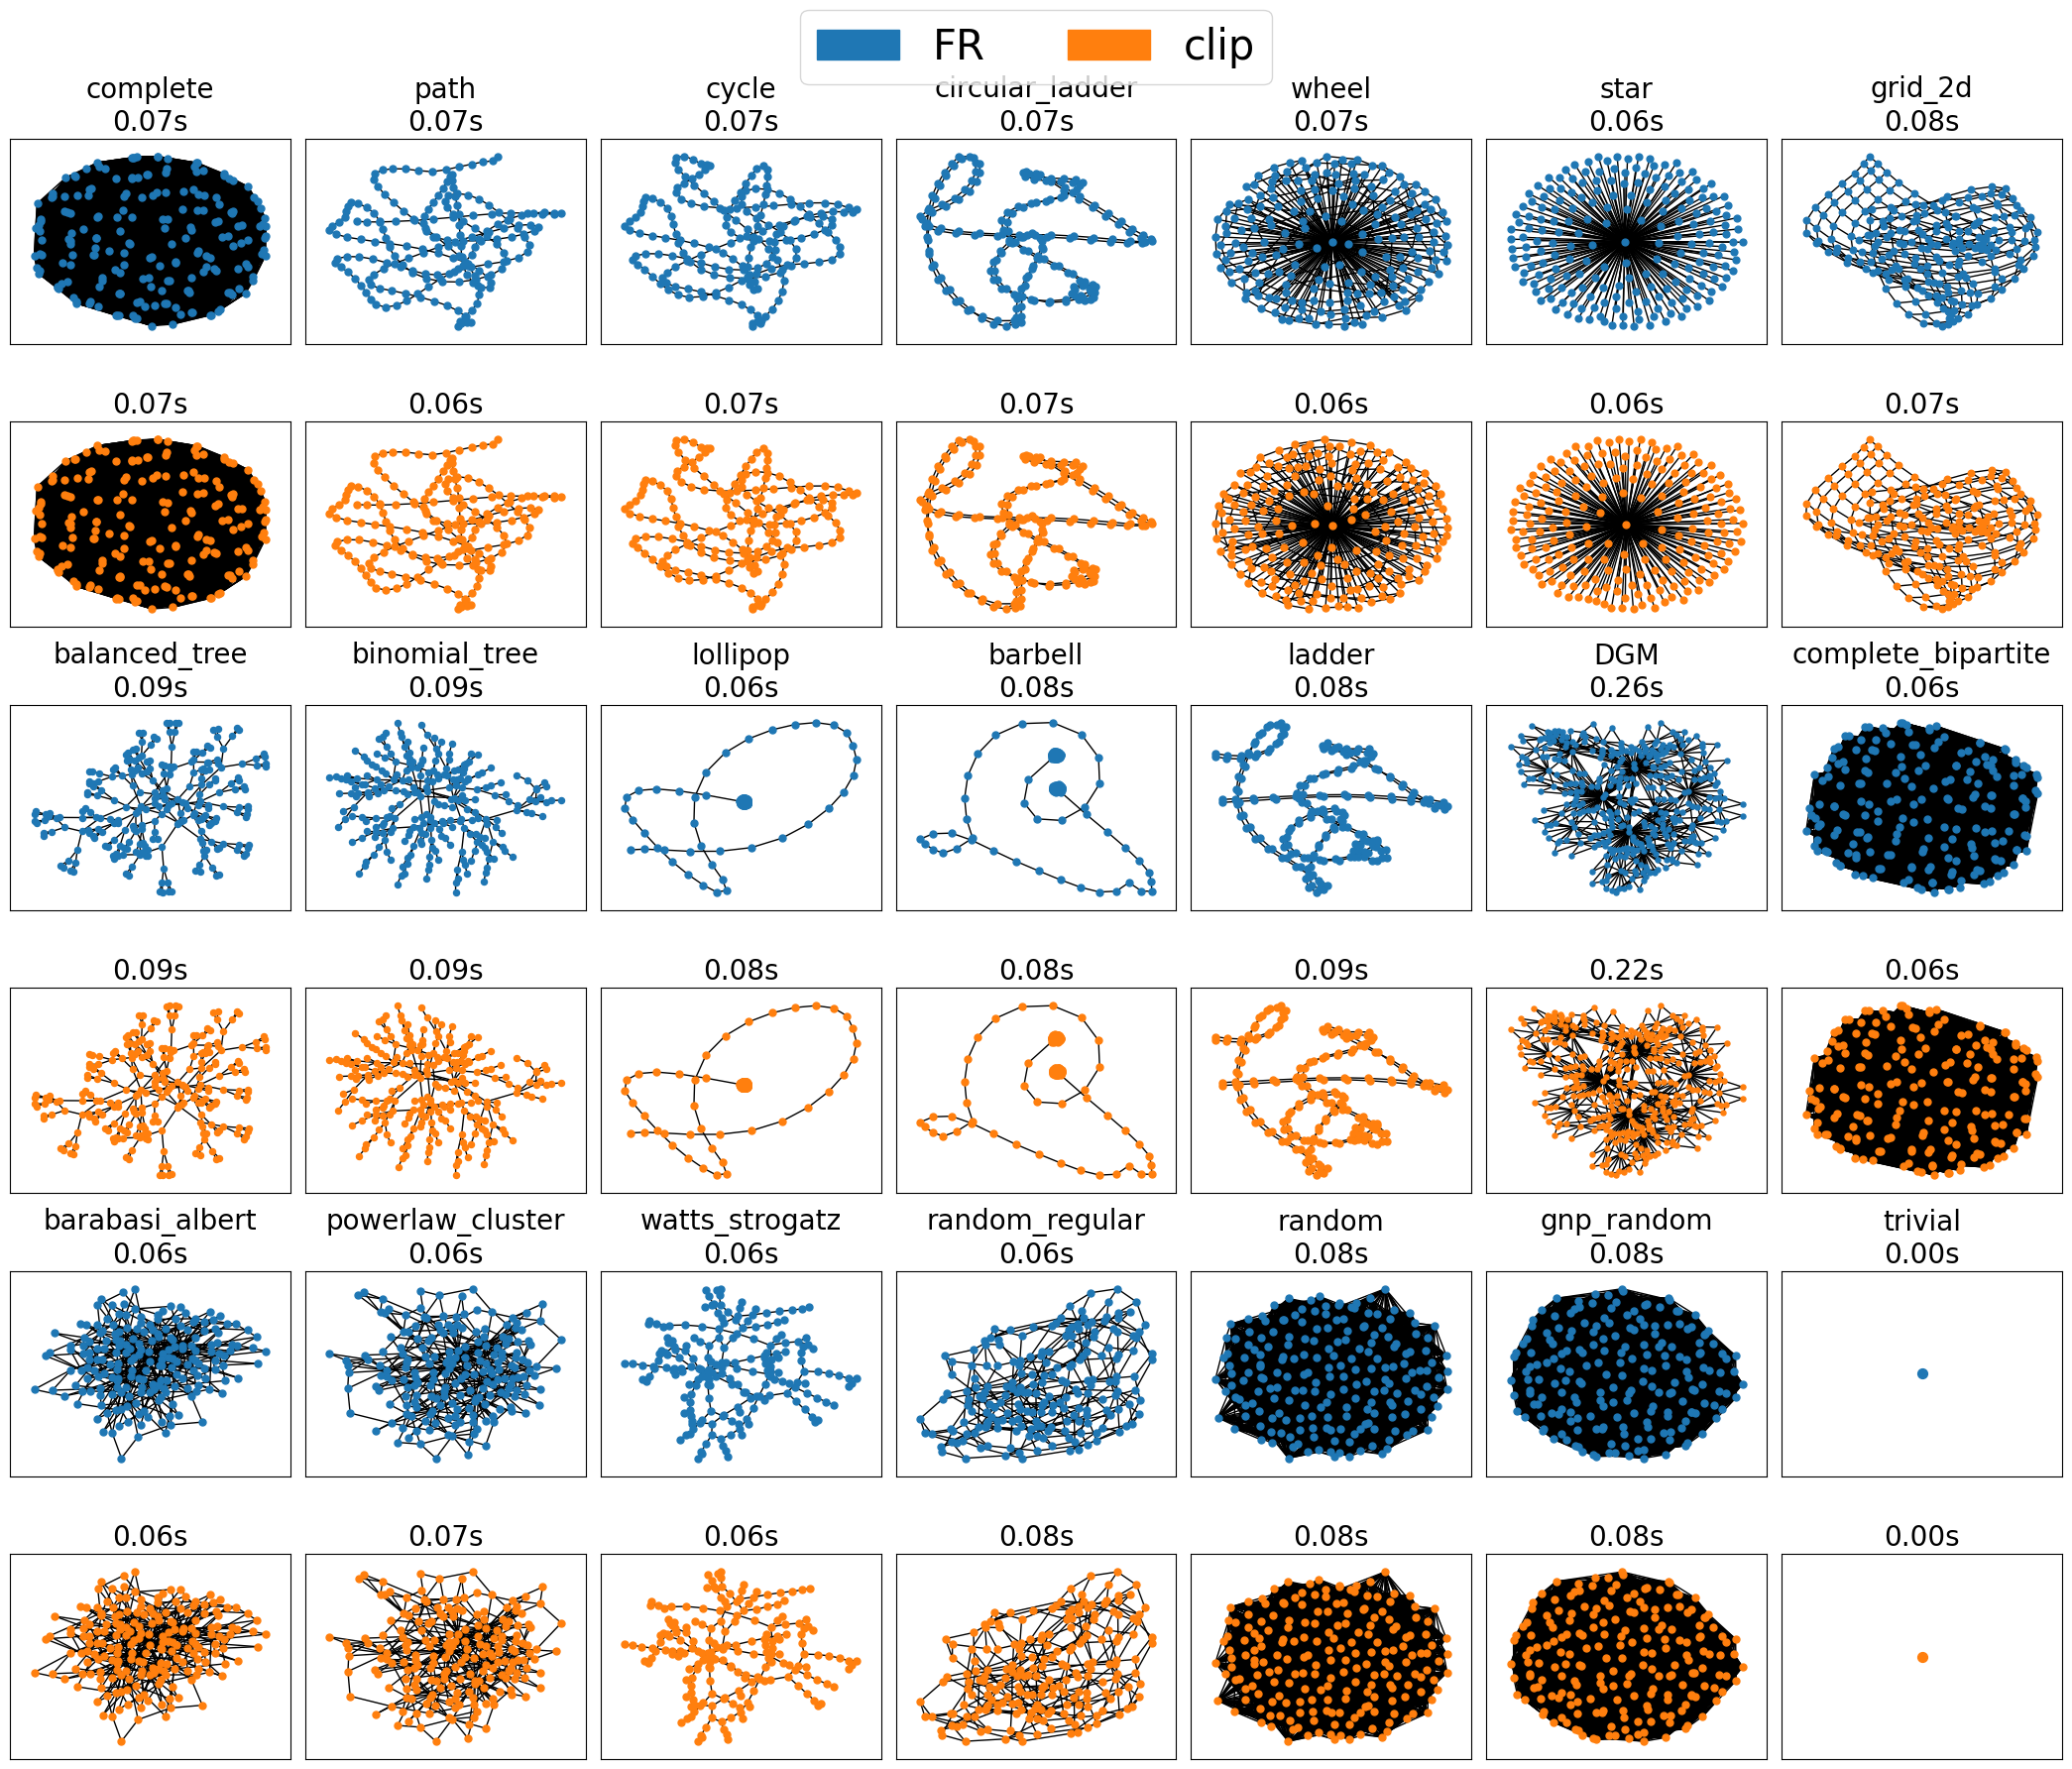

In [34]:
def shuffle_nodes(G):
    nodes = list(G.nodes)
    np.random.shuffle(nodes)
    mapping = {node: new_node for node, new_node in zip(G.nodes, nodes)}
    return nx.relabel_nodes(G, mapping)


def graph_generator(n: int):
    graph_functions = [
        (nx.complete_graph, [n]),
        (nx.path_graph, [n]),
        (nx.cycle_graph, [n]),
        (nx.circular_ladder_graph, [n // 2]),
        (nx.wheel_graph, [n]),
        (nx.star_graph, [n]),
        (nx.grid_2d_graph, [int(np.sqrt(n) + 1), int(np.sqrt(n) + 1)]),
        (nx.balanced_tree, [2, int(np.log2(n))]),
        (nx.binomial_tree, [int(np.log2(n) + 1)]),
        (nx.lollipop_graph, [4 * n // 5, n // 5]),
        (nx.barbell_graph, [2 * n // 5, n // 5]),
        (nx.ladder_graph, [n // 2]),
        (nx.dorogovtsev_goltsev_mendes_graph, [int(np.log(2 * n) / np.log(3) + 1)]),
        (nx.complete_bipartite_graph, [n // 2, n // 2]),
        (nx.barabasi_albert_graph, [n, 2]),
        (nx.powerlaw_cluster_graph, [n, 2, 0.5]),
        (nx.watts_strogatz_graph, [n, 2, 0.5]),
        (nx.random_regular_graph, [3, n]),
        (nx.bipartite.random_graph, [n // 2, n // 2, 0.5]),
        (nx.gnp_random_graph, [n, 0.5]),
        (nx.trivial_graph, []),
    ]
    return [
        (shuffle_nodes(func(*args)), func.__name__) for func, args in graph_functions
    ]


def make_methods(iterations: int):
    return [
        (nx.spring_layout, "FR", "tab:blue", {"iterations": iterations, "seed": 0}),
        (
            spring_layout,
            "clip",
            "tab:orange",
            {"iterations": iterations, "clipping_value": 0.01, "seed": 0},
        ),
    ]


make_fig(graph_generator(10), make_methods(50), "graphs_10", 1.0, 0.96, 3)
make_fig(graph_generator(100), make_methods(50), "graphs_50", 1.0, 0.96, 3)
make_fig(graph_generator(200), make_methods(50), "graphs_300", 1.0, 0.96, 3)

In [35]:
def trial(seed, val):
    n = 10
    A = np.zeros((n, n))
    for i in range(n):
        A[i][(i + 1) % n] = val

    G1 = nx.from_numpy_array(A)
    G2 = nx.from_numpy_array(A)

    pos1 = spring_layout(G1, k=1e-2, clipping_value=0.1, seed=seed)
    pos2 = spring_layout(G2, k=1e-2, clipping_value=0.01, seed=seed)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    nx.draw(G1, pos=pos1, node_size=500, with_labels=True)
    plt.title("Original")
    plt.subplot(1, 2, 2)
    nx.draw(G2, pos=pos2, node_size=500, with_labels=True)
    plt.title("Fixed")
    # plt.show()
    plt.savefig(f"{val}_{seed}.png")
    plt.close()


for seed in range(10):
    print(f"Trial {seed + 1}")
    trial(seed, 1e-3)

for seed in range(1):
    print(f"Trial {seed + 1}")
    trial(seed, 1e-5)

Trial 1
Iter 0: 3 nodes have length < 0.01
Iter 1: 4 nodes have length < 0.01
Iter 2: 4 nodes have length < 0.01
Iter 3: 8 nodes have length < 0.01
Iter 4: 10 nodes have length < 0.01
Iter 5: 10 nodes have length < 0.01
Iter 6: 10 nodes have length < 0.01
Iter 7: 10 nodes have length < 0.01
Iter 8: 10 nodes have length < 0.01
Iter 9: 10 nodes have length < 0.01
Iter 10: 10 nodes have length < 0.01
Iter 11: 10 nodes have length < 0.01
Iter 12: 10 nodes have length < 0.01
Iter 13: 10 nodes have length < 0.01
Iter 14: 10 nodes have length < 0.01
Iter 15: 10 nodes have length < 0.01
Iter 16: 10 nodes have length < 0.01
Iter 17: 10 nodes have length < 0.01
Iter 18: 10 nodes have length < 0.01
Iter 19: 10 nodes have length < 0.01
Iter 20: 10 nodes have length < 0.01
Iter 21: 10 nodes have length < 0.01
Iter 22: 10 nodes have length < 0.01
Iter 23: 10 nodes have length < 0.01
Iter 24: 10 nodes have length < 0.01
Iter 25: 10 nodes have length < 0.01
Iter 26: 10 nodes have length < 0.01
Iter 27